#  Word2vec

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://radimrehurek.com/gensim/models/word2vec.html
* https://radimrehurek.com/gensim/auto_examples/tutorials/run_word2vec.html
* https://github.com/OlgaChernytska/word2vec-pytorch
* https://www.baeldung.com/cs/nlps-word2vec-negative-sampling
* https://towardsdatascience.com/implementing-word2vec-in-pytorch-from-the-ground-up-c7fe5bf99889

## Задачи для совместного разбора

1\. Рассмотрите основные шаги подготовки данных для обучения skip-gram модели

In [123]:
text = "Рассмотрите основные шаги подготовки данных для обучения".lower()
tokens = text.split()
tokens

['рассмотрите', 'основные', 'шаги', 'подготовки', 'данных', 'для', 'обучения']

In [124]:
indices = [tokens.index(tok) for tok in tokens]
indices

[0, 1, 2, 3, 4, 5, 6]

In [125]:
import torch as th
# k = 3

x = []
y = []
for idx in range(1, len(indices)-1):
  x.append(indices[idx])
  y.append(indices[idx-1])
  x.append(indices[idx])
  y.append(indices[idx+1])
x = th.tensor(x)
y = th.tensor(y)

In [126]:
x

tensor([1, 1, 2, 2, 3, 3, 4, 4, 5, 5])

In [127]:
y

tensor([0, 2, 1, 3, 2, 4, 3, 5, 4, 6])

2\. Рассмотрите основные шаги по настройке skip-gram модели

In [128]:
import torch.nn as nn

vocab_size = len(set(tokens))

embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=2)
linear = nn.Linear(in_features=2, out_features=vocab_size)

e = embedding(x)
out = linear(e)
out

tensor([[-0.3188,  0.3268,  0.8733, -1.1985, -0.3740,  0.2185,  1.1825],
        [-0.3188,  0.3268,  0.8733, -1.1985, -0.3740,  0.2185,  1.1825],
        [ 0.2720,  0.2426, -1.4511,  0.8933,  0.5787, -0.6738, -1.1894],
        [ 0.2720,  0.2426, -1.4511,  0.8933,  0.5787, -0.6738, -1.1894],
        [-0.5501,  0.7113,  0.8160, -1.2506, -0.5349,  0.6355,  1.1005],
        [-0.5501,  0.7113,  0.8160, -1.2506, -0.5349,  0.6355,  1.1005],
        [-0.3240,  0.8870, -0.6449,  0.0028, -0.0451,  0.3342, -0.4040],
        [-0.3240,  0.8870, -0.6449,  0.0028, -0.0451,  0.3342, -0.4040],
        [-0.6714,  1.0601,  0.3817, -0.9575, -0.5307,  0.8827,  0.6353],
        [-0.6714,  1.0601,  0.3817, -0.9575, -0.5307,  0.8827,  0.6353]],
       grad_fn=<AddmmBackward0>)

## Задачи для самостоятельного решения

In [129]:
import pandas as pd
import nltk
import gensim
import pymorphy3
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer, word_tokenize
from nltk.util import ngrams
import torch as th
from gensim.models import Word2Vec
import random
from functools import reduce
from torch.utils.data import Dataset
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import itertools
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

[nltk_data] Downloading package stopwords to C:\Users\Rog
[nltk_data]     G16\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<p class="task" id="1"></p>

1\. Загрузите тексты новостей из файла `news_500.csv`. Удалите из текстов все знаки препинания и символы не из русского алфавита, приведите все слова к нижнему регистру и удалите стоп-слова.

- [ ] Проверено на семинаре

In [130]:
tokenizer = RegexpTokenizer(r"[А-я]+")

morph = pymorphy3.MorphAnalyzer()

ru_stops = set(stopwords.words('russian'))
            
text2index = {}
index2text = {}
for idx, text in enumerate(pd.read_csv("data/news_500.csv")['text'].values):
    
    sirye = tokenizer.tokenize(text)
    
    tokens = []
    for word in sirye :
        word = word.lower()
        if word not in ru_stops:
            tokens.append(morph.parse(word)[0].normal_form)
    text2index[text] = idx
    index2text[idx] = text, tokens

In [131]:
df = pd.DataFrame.from_dict(index2text, orient='index', columns=['text', 'tokens'])
df.tokens[3]

['слово',
 'р',
 'вяхирев',
 'это',
 'открытый',
 'тендер',
 'кто',
 'деньга',
 'купить',
 'однако',
 'глава',
 'газовый',
 'концерн',
 'отказаться',
 'сказать',
 'какой',
 'холдинг',
 'идти',
 'речь',
 'рэм',
 'вяхирев',
 'очередной',
 'подтвердить',
 'вопрос',
 'возврат',
 'газпром',
 'долг',
 'медиа',
 'мост',
 'продажа',
 'акция',
 'являться',
 'экономический',
 'процесс',
 'лежать',
 'политический',
 'плоскость',
 'напомнить',
 'близкий',
 'время',
 'начаться',
 'рассмотрение',
 'иск',
 'оао',
 'газпром',
 'медиа',
 'взыскание',
 'зао',
 'медиа',
 'мост',
 'млн',
 'долл',
 'основный',
 'долг',
 'млн',
 'долл',
 'процент',
 'пользование',
 'денежный',
 'средство',
 'ранее',
 'московский',
 'арбитражный',
 'суд',
 'принять',
 'решение',
 'наложение',
 'арест',
 'акция',
 'медиа',
 'мост',
 'объявить',
 'гендиректор',
 'газпром',
 'медиа',
 'альфред',
 'кох',
 'арестовать',
 'принадлежащий',
 'гибралтарский',
 'оффшорный',
 'фирма',
 'акция',
 'нтв',
 'нтв',
 'плюс',
 'тнт',
 'другой

<p class="task" id="2"></p>

2\. Настройте модель Word2Vec из пакета `gensim`. Для валидации выведите на экран информацию о ближайших словах для нескольких случайно выбранных токенов из обучающей выборки.

- [ ] Проверено на семинаре

In [132]:
model = Word2Vec(sentences=df.tokens.values.tolist(), vector_size=100, window=5, min_count=1, workers=4)

for word in random.choices(list(reduce(lambda x,y: x+y, df.tokens.values.tolist())),k=3):
    print(f"{word} : {model.wv.most_similar(word, topn=3)}")

страна : [('быть', 0.9999071955680847), ('случай', 0.9999006390571594), ('который', 0.9998943209648132)]
сторонник : [('момент', 0.9988527297973633), ('тысяча', 0.9988117814064026), ('область', 0.9987934827804565)]
соколовский : [('доменный', 0.9686830043792725), ('чернобыльский', 0.9686172008514404), ('смысл', 0.968237578868866)]


In [133]:
Counter(itertools.chain.from_iterable(df.tokens.values.tolist()))

Counter({'россия': 568,
         'рбк': 530,
         'год': 528,
         'который': 499,
         'сообщить': 379,
         'рф': 358,
         'также': 323,
         'отметить': 322,
         'это': 320,
         'время': 311,
         'слово': 310,
         'российский': 299,
         'доллар': 296,
         'сша': 292,
         'президент': 262,
         'заявить': 254,
         'вопрос': 248,
         'решение': 247,
         'рынок': 245,
         'сегодня': 240,
         'компания': 239,
         'страна': 239,
         'день': 230,
         'мнение': 225,
         'глава': 222,
         'такой': 212,
         'правительство': 205,
         'депутат': 205,
         'свой': 198,
         'быть': 192,
         'дело': 192,
         'однако': 189,
         'должный': 178,
         'госдума': 173,
         'считать': 172,
         'суд': 171,
         'напомнить': 170,
         'первый': 168,
         'москва': 161,
         'являться': 160,
         'цена': 160,
         'служба':

In [134]:
word = 'путин'
print(f"{word} : {model.wv.most_similar(word, topn=3)}")

путин : [('президент', 0.9994854927062988), ('рф', 0.9994145631790161), ('слово', 0.9993773698806763)]


<p class="task" id="3"></p>

3. Опишите класс `W2VDataset`, который реализует в себе логику получения контекстного окна для обучения skip-gram модели. При создании словаря игнорируйте токены, которые встретились меньше 20 раз. Продемонстрируйте пример работы.

![image.png](https://github.com/OlgaChernytska/word2vec-pytorch/raw/main/docs/skipgram_overview.png)

- [ ] Проверено на семинаре

In [135]:
class W2VDataset(Dataset):
    def __init__(self, corpus: list[list[str]], window_size: int = 2, min_count: int = 20):
        """
        Parameters
        ----------
        corpus
            Список предложений, где каждое предложение - список токенов.
        window_size
            Размер окна контекста слева и справа.
        min_count
            Минимальная частота слова для включения в словарь.
        """
        self.corpus = corpus
        self.window_size = window_size
        self.min_count = min_count
        
        word_counts = Counter(itertools.chain.from_iterable(corpus))
        self.vocab = [word for word, count in word_counts.items() if count >= self.min_count]
        
        self.word2idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx2word = {idx: word for idx, word in enumerate(self.vocab)}
        
        self.vocab_size = len(self.vocab)
        
        self.data = self._generate_pairs()

    def _generate_pairs(self) -> list[tuple[int, int]]:
        pairs = []
        for sentence in self.corpus:
            for i in range(len(sentence)):
                for j in range(max(0, i - self.window_size), min(len(sentence), i + self.window_size + 1)):
                    if i!=j and sentence[i] in self.vocab and sentence[j] in self.vocab:
                        pairs.append((self.word2idx[sentence[i]], self.word2idx[sentence[j]]))
        return pairs

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        center_word, context_word = self.data[idx]
        return torch.tensor(center_word, dtype=torch.long), torch.tensor(context_word, dtype=torch.long)
    

dataset = W2VDataset(df.tokens.values.tolist(),window_size=3)

In [136]:
len(dataset)

177902

In [137]:
dataset[1]

(tensor(0), tensor(2))

<p class="task" id="4"></p>

4\. Реализуйте и настройте skip-gram модель. Перед началом обучения выберите случайным образом несколько слов из датасета и для каждого из них выведите на экран 3 ближайших слова в смысле косинусной близости между эмбеддингами. В процессе настройки для валидации периодически выводите на экран информацию о ближайших словах для этих слов. Выведите на экран график значения функции потерь в зависимости от номера эпохи.  

![image.png](https://github.com/OlgaChernytska/word2vec-pytorch/raw/main/docs/skipgram_detailed.png)

- [ ] Проверено на семинаре

In [138]:
class Skip_Gram(pl.LightningModule):
    def __init__(self, vocab_size: int, embed_dim: int, dataset: W2VDataset, val_words: list[str] | None = None):
        super().__init__()
        self.dataset = dataset
        self.val_words = val_words if val_words else random.choices(dataset.vocab, k=3)
        
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.linear = nn.Linear(in_features=embed_dim, out_features=vocab_size)
        self.criterion = nn.CrossEntropyLoss()
        
        self.epoch_losses =[]
        self.current_epoch_losses =[]
        
    def forward(self, center_word_idx: torch.Tensor) -> torch.Tensor:
        embeds = self.embedding(center_word_idx) 
        logits = self.linear(embeds) 
        return logits

    def training_step(self, batch, batch_idx):
        center_words, context_words = batch
        
        logits = self(center_words)
        loss = self.criterion(logits, context_words)
        self.current_epoch_losses.append(loss.item())

        self.log('train_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)
        
        
    def on_train_epoch_end(self):
        avg_loss = sum(self.current_epoch_losses) / len(self.current_epoch_losses)
        self.epoch_losses.append(avg_loss)
        self.current_epoch_losses.clear()
        
        print(f"\nЭпоха {self.current_epoch} (Loss: {avg_loss:.4f})")
        
        all_embeddings = self.embedding.weight 
        message_len = len(max(self.val_words, key=len))
        for word in self.val_words:
            if word not in self.dataset.word2idx:
                continue
                
            word_idx = self.dataset.word2idx[word]
            word_vec = all_embeddings[word_idx] 
            
            similarities = F.cosine_similarity(all_embeddings, word_vec.unsqueeze(0))
            
            top_indices = torch.topk(similarities, k=4).indices.tolist()
            
            top_words =[(self.dataset.idx2word[idx], similarities[idx]) for idx in top_indices if idx != word_idx][:3]
            
            
            print(f"{"Ближайшие к " + word + ":":^{message_len+16}}", end="")
            for i in top_words:
                print(f"{i[0]} ({i[1]}), ",end="")
            print()

In [139]:
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True, num_workers=0)

model = Skip_Gram(
    vocab_size=dataset.vocab_size, 
    embed_dim=500, 
    dataset=dataset
)

trainer = pl.Trainer(
    max_epochs=30, 
    accelerator='auto',
    enable_checkpointing=False,
    logger=True
)

trainer.fit(model, dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | embedding | Embedding        | 394 K  | train
1 | linear    | Linear           | 394 K  | train
2 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
788 K     Trainable params
0         Non-trainable params
788 K     Total params
3.155     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]


Эпоха 0 (Loss: 6.3576)
  Ближайшие к новый:   ранее (0.15771619975566864), войско (0.14723852276802063), мвд (0.12980389595031738), 
   Ближайшие к так:    пройти (0.1360846608877182), опек (0.12800262868404388), полномочие (0.1121218353509903), 
 Ближайшие к очередь:  случай (0.14151877164840698), тысяча (0.13561001420021057), база (0.13262911140918732), 

Эпоха 1 (Loss: 5.7252)
  Ближайшие к новый:   ранее (0.159429669380188), войско (0.14914193749427795), мвд (0.13182194530963898), 
   Ближайшие к так:    пройти (0.13813579082489014), опек (0.12964531779289246), край (0.11403150856494904), 
 Ближайшие к очередь:  случай (0.14161023497581482), база (0.13415610790252686), тысяча (0.13357287645339966), 

Эпоха 2 (Loss: 5.4643)
  Ближайшие к новый:   ранее (0.16067363321781158), войско (0.15112338960170746), мвд (0.13238804042339325), 
   Ближайшие к так:    пройти (0.14050082862377167), опек (0.1317361444234848), край (0.11671368777751923), 
 Ближайшие к очередь:  случай (0.1411657333

`Trainer.fit` stopped: `max_epochs=30` reached.



Эпоха 29 (Loss: 4.8406)
  Ближайшие к новый:   ранее (0.14396242797374725), войско (0.14207801222801208), федерация (0.12473197281360626), 
   Ближайшие к так:    пройти (0.1393742561340332), опек (0.13271334767341614), многие (0.12255170941352844), 
 Ближайшие к очередь:  тысяча (0.13051626086235046), случай (0.12464050948619843), база (0.12291721999645233), 


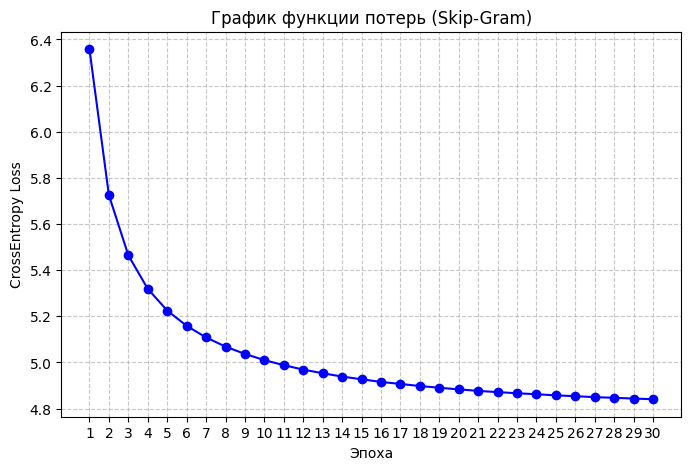

In [140]:

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model.epoch_losses) + 1), model.epoch_losses, marker='o', color='b')
plt.title("График функции потерь (Skip-Gram)")
plt.xlabel("Эпоха")
plt.ylabel("CrossEntropy Loss")
plt.xticks(range(1,len(model.epoch_losses)+1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


<p class="task" id="5"></p>

5\. Выберите одно слово из набора данных и найдите к нему топ-20 ближайших в смысле косинусной близости между эмбеддингами. Извлеките веса обученного слоя эмбеддингов из модели, обученной в предыдущем задании.

Используя PCA или t-SNE (из sklearn), сожмите вектора до размерности 2. Обратите внимание, что для обучения этих моделей нужно использовать весь набор векторов, а не только топ отобранных.

Визуализируйте отобранные слова. Прокомментируйте (текстом) полученный результат.

- [ ] Проверено на семинаре

топ-20 ближайших


In [141]:
all_embeddings = model.embedding.weight 

word = random.choice(dataset.vocab)
    
n = 20


word_idx = model.dataset.word2idx[word]
word_vec = all_embeddings[word_idx] 

similarities = F.cosine_similarity(all_embeddings, word_vec.unsqueeze(0))

top_indices = torch.topk(similarities, k=n+1).indices.tolist()

top_words =[(model.dataset.idx2word[idx], similarities[idx]) for idx in top_indices if idx != word_idx][:n]


print(f"Ближайшие к {word}:")
for i in top_words:
    print(" "*10 + f"{i[0]} ({i[1]})")

Ближайшие к итог:
          единый (0.132492333650589)
          эксперт (0.1270228922367096)
          запланировать (0.12418407946825027)
          катастрофа (0.11849334836006165)
          известно (0.11709524691104889)
          тот (0.11655508726835251)
          технический (0.11332543194293976)
          заключение (0.11285986751317978)
          отмечать (0.11050020903348923)
          швейцарский (0.10799948126077652)
          расход (0.10772468149662018)
          строительство (0.10681396722793579)
          произвести (0.1050369068980217)
          бывший (0.10275322198867798)
          намерение (0.10114667564630508)
          действие (0.10101097822189331)
          николай (0.10029920190572739)
          ноябрь (0.09895709156990051)
          таможенный (0.09859240800142288)
          банк (0.09786976873874664)


PCA

In [142]:
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(all_embeddings.detach())
embeddings_pca.shape

(788, 2)

итог [ 0.94909313 -0.16773987]
единый [1.00595759 2.81862545]
эксперт [-0.00343029  0.35859662]
запланировать [2.75532663 0.4185967 ]
катастрофа [1.64080889 0.47278144]
известно [-1.21960286  2.04695796]
тот [1.32946051 1.38978721]
технический [ 1.16488696 -0.71016414]
заключение [-0.18475401  0.47401546]
отмечать [ 1.2662336  -0.70262002]
швейцарский [0.89790644 1.21659685]
расход [2.86623627 1.35017377]
строительство [ 0.99834671 -0.23853578]
произвести [-2.21908259  3.51500871]
бывший [-2.06381845  2.20892059]
намерение [-0.502344   -1.52215352]
действие [1.09121524 1.08065327]
николай [-0.15003523  2.55253665]
ноябрь [ 1.17621915 -0.03266964]
таможенный [ 2.20658703 -3.08842378]
банк [1.07079043 0.59130035]


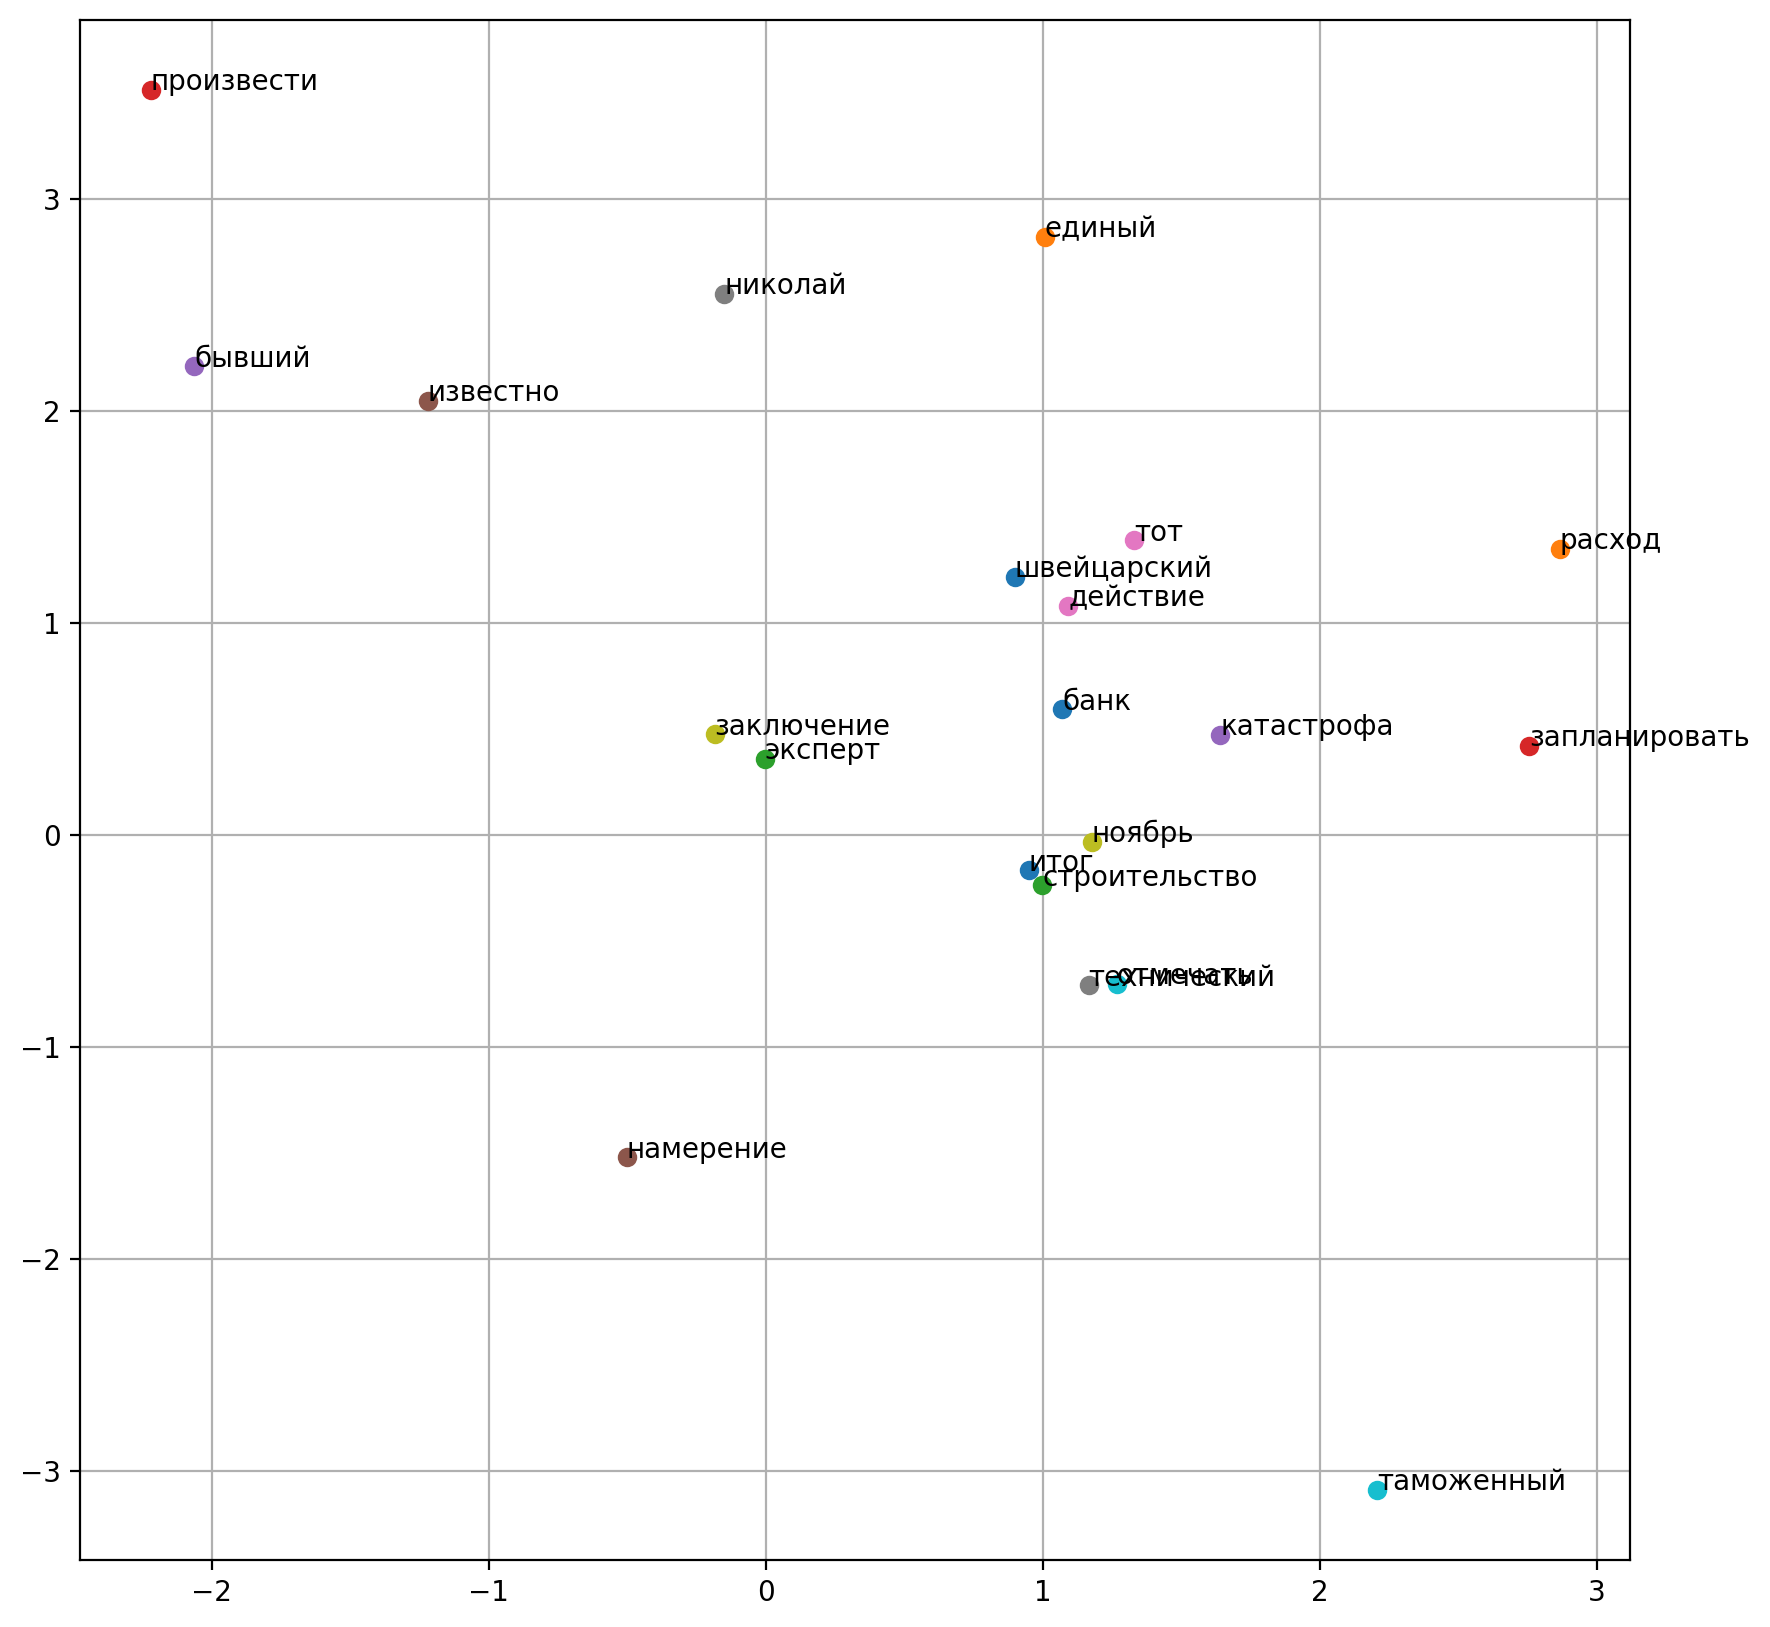

In [143]:
plt.figure(figsize=(10,10), dpi=200)
for idx in top_indices:
    print(model.dataset.idx2word[idx], embeddings_pca[idx])
    plt.plot(embeddings_pca[idx][0],embeddings_pca[idx][1], 'o')
    plt.annotate(model.dataset.idx2word[idx], embeddings_pca[idx])
plt.grid(True)
plt.show()

t-sne

In [144]:
embeddings_tsne = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=3).fit_transform(all_embeddings.detach())
embeddings_tsne.shape

(788, 2)

итог [-3.2016315 11.8729315]
единый [ 4.250472 23.281324]
эксперт [-37.859158  -5.483048]
запланировать [-29.286266 -27.21297 ]
катастрофа [-1.4492776 12.538582 ]
известно [10.876766 42.944656]
тот [-1.3769639 12.245245 ]
технический [ -4.9957013 -17.419807 ]
заключение [15.140574 21.265245]
отмечать [33.780567   4.8035107]
швейцарский [-15.057454  35.310326]
расход [10.157746 21.151339]
строительство [  4.9285192 -21.920958 ]
произвести [-1.4445038 10.032664 ]
бывший [-7.2413077 24.887877 ]
намерение [  1.408955 -10.302605]
действие [-5.729331   6.7793136]
николай [-13.045686  24.431622]
ноябрь [-17.751877 -23.983486]
таможенный [35.371227  7.108195]
банк [ 7.5059967 30.838453 ]


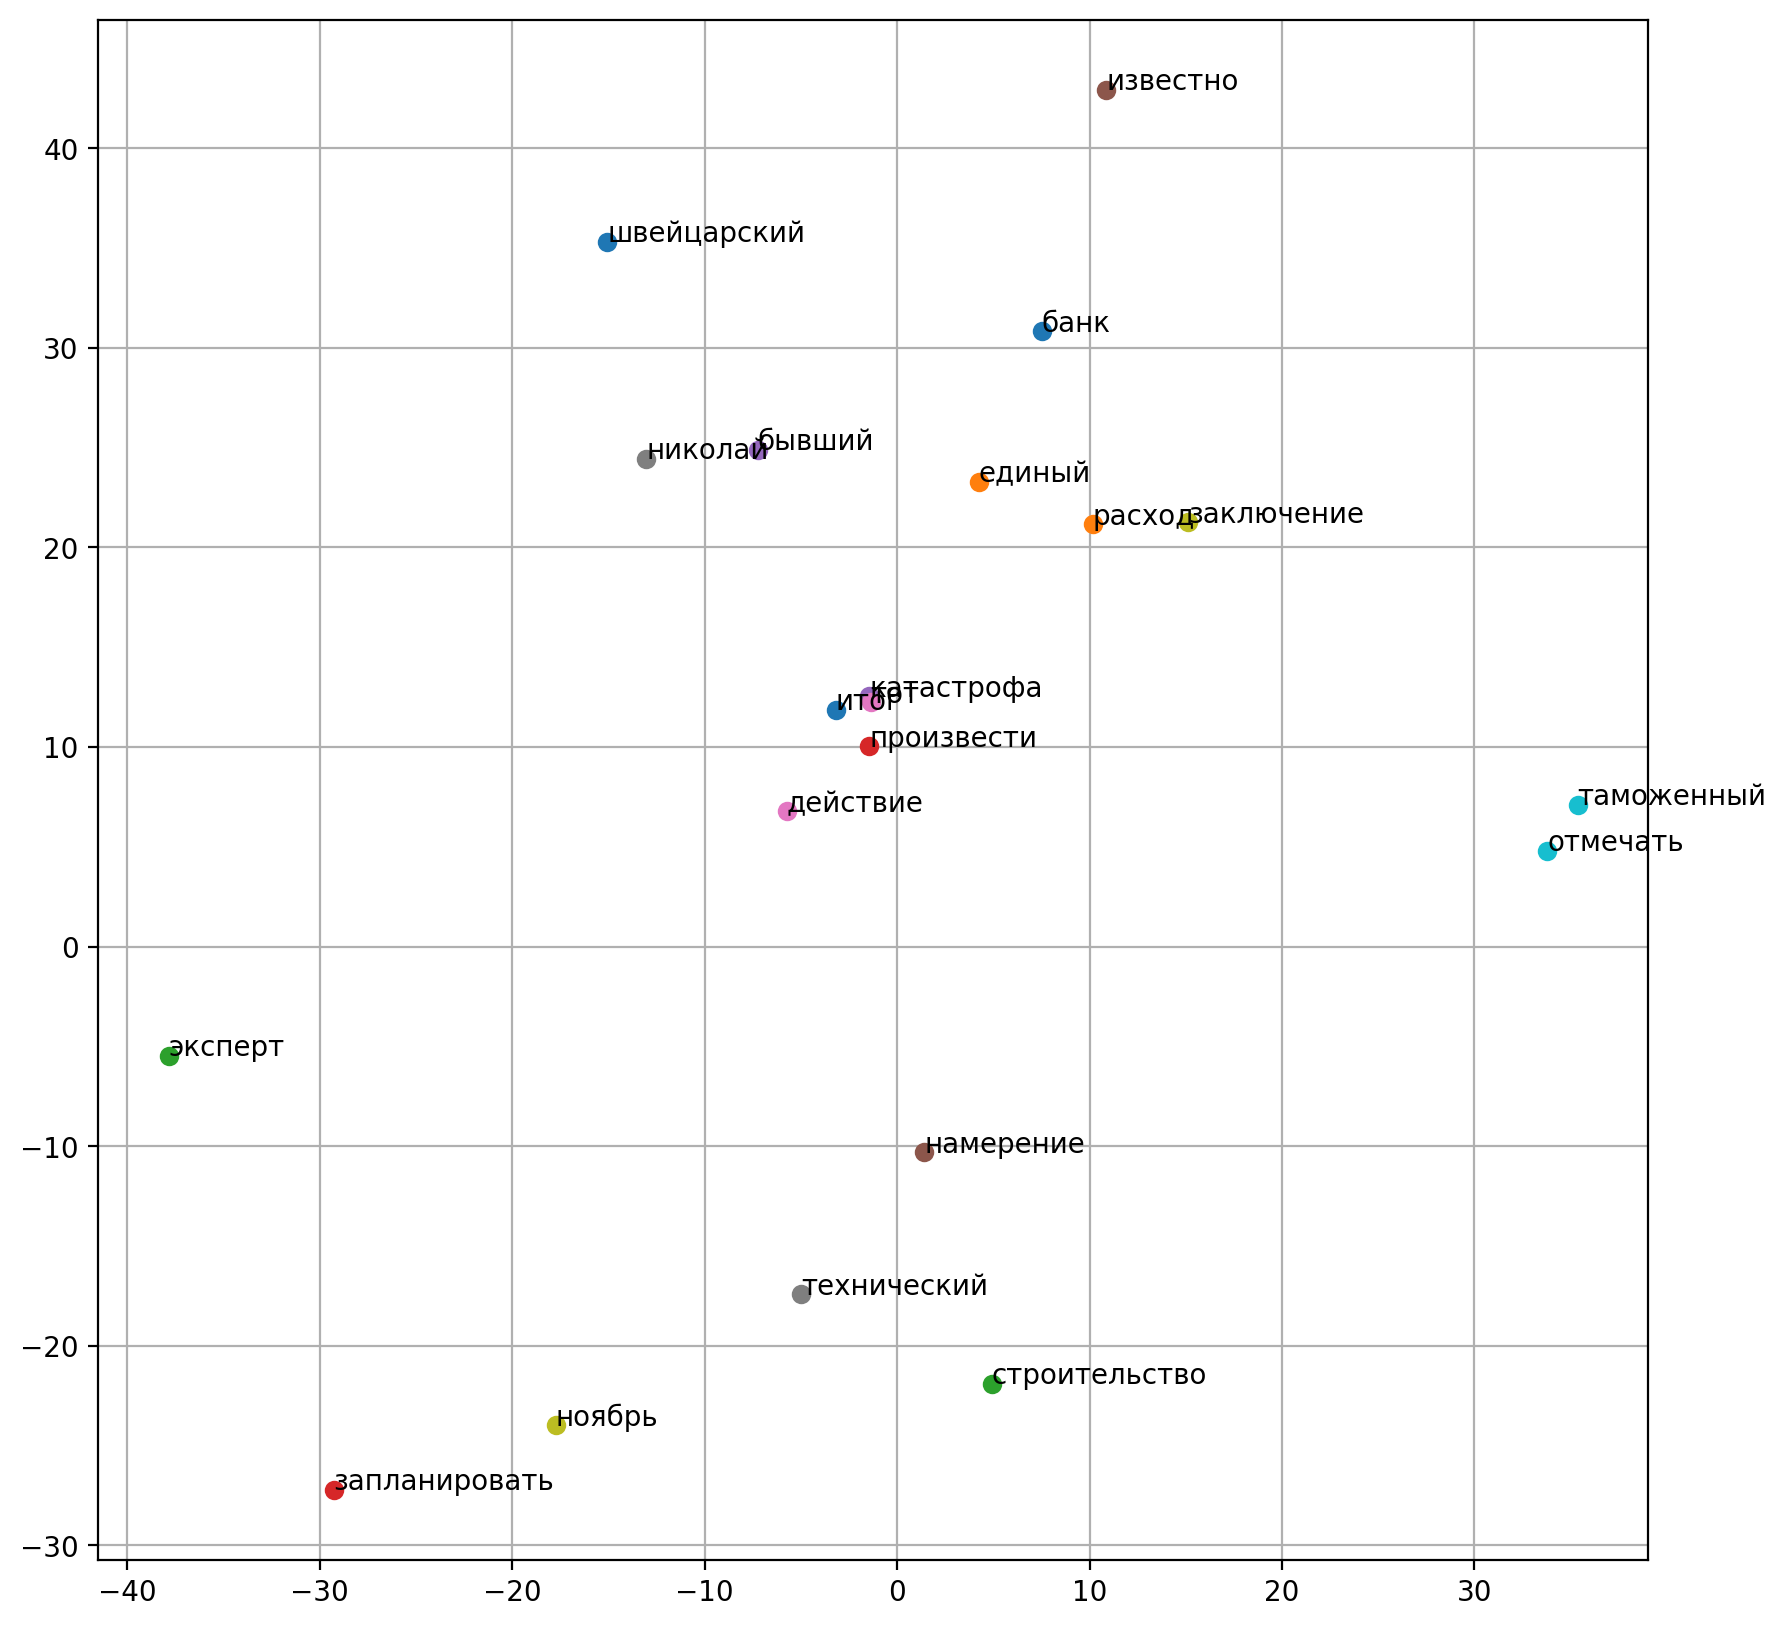

In [145]:
plt.figure(figsize=(10,10), dpi=200)
for idx in top_indices:
    print(model.dataset.idx2word[idx], embeddings_tsne[idx])
    plt.plot(embeddings_tsne[idx][0],embeddings_tsne[idx][1], 'o')
    plt.annotate(model.dataset.idx2word[idx], embeddings_tsne[idx])
plt.grid(True)
plt.show()

PCA показал себя лучше, чем t-sne, но обучающего корпуса мало для адекватного представления близости слов